In [32]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [33]:
df = pd.read_csv("../Data/horror_movies.csv")
df.drop(['adult', 'collection', 'poster_path','backdrop_path'], axis=1, inplace=True)
df.dropna(subset=['overview'], inplace=True)
df['release_date'] = pd.to_datetime(df['release_date'])
df_released = df.drop(df[df['status'] != 'Released'].index).reset_index(drop=True)
movie_df = df_released

movie_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 31142 entries, 0 to 31141
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 31142 non-null  int64         
 1   original_title     31142 non-null  str           
 2   title              31142 non-null  str           
 3   original_language  31142 non-null  str           
 4   overview           31142 non-null  str           
 5   tagline            12628 non-null  str           
 6   release_date       31142 non-null  datetime64[us]
 7   popularity         31142 non-null  float64       
 8   vote_count         31142 non-null  int64         
 9   vote_average       31142 non-null  float64       
 10  budget             31142 non-null  int64         
 11  revenue            31142 non-null  int64         
 12  runtime            31142 non-null  int64         
 13  status             31142 non-null  str           
 14  genre_names      

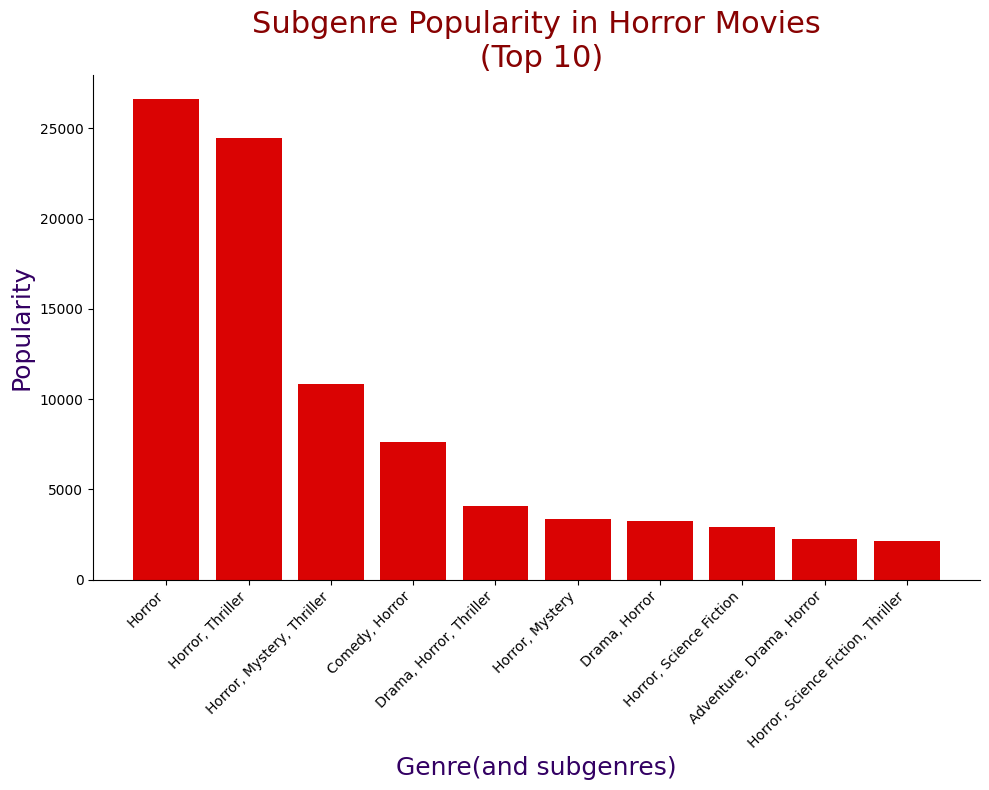

In [ ]:
top_pop_genre = movie_df.groupby("genre_names")["popularity"].sum().sort_values(ascending=False).head(10)


plt.figure(figsize=(10,8))
plt.bar(top_pop_genre.index, top_pop_genre.values, color=  "#da0303")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Genre(and subgenres)", fontsize= 18, color=  "#330063")
plt.ylabel("Popularity", fontsize= 18, color=  "#330063")
plt.title("Subgenre Popularity in Horror Movies\n (Top 10)", fontsize= 22, color=  "#880202", pad=25)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig('../visuals/subgenrepopularity.png')
plt.show()


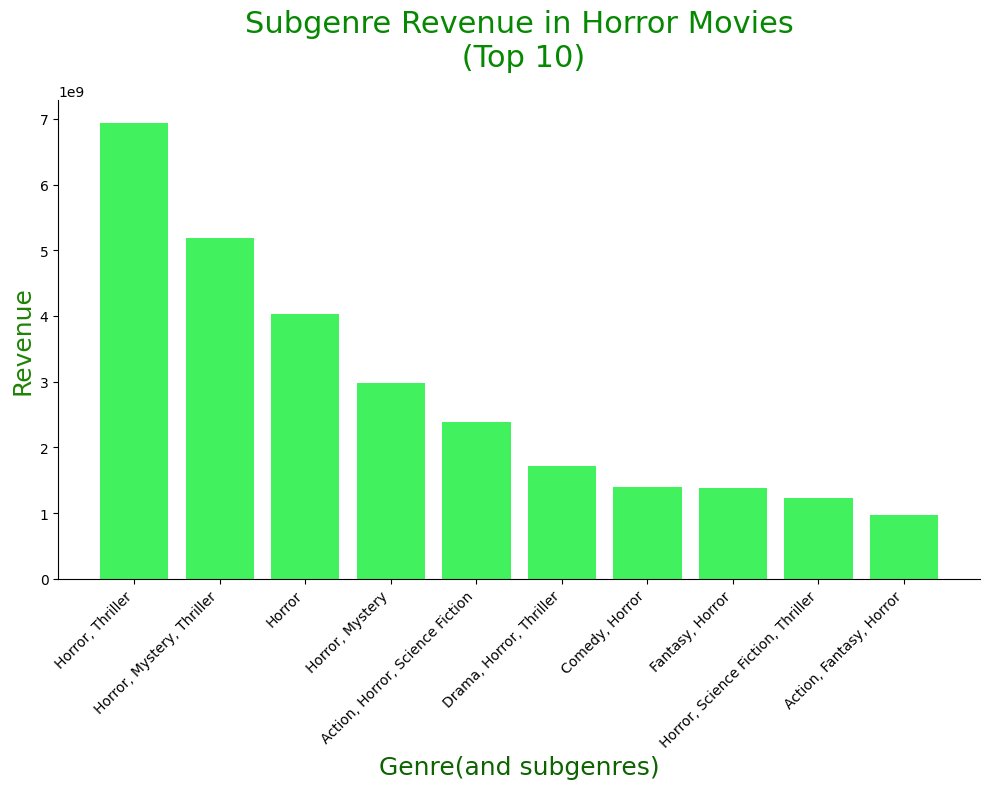

In [ ]:
top_rev_genre = movie_df.groupby("genre_names")["revenue"].sum().sort_values(ascending=False).head(10)


plt.figure(figsize=(10,8))
plt.bar(top_rev_genre.index, top_rev_genre.values, color=  "#41f15e")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Genre(and subgenres)", fontsize= 18, color=  "#0C6300")
plt.ylabel("Revenue", fontsize= 18, color=  "#1E8304")
plt.title("Subgenre Revenue in Horror Movies\n (Top 10)", fontsize= 22, color=  "#078802", pad=25)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig('../visuals/subgenrerevenue.png')
plt.show()

#how does this compare to subgenre popularity?
#should be very similar
## BUT consider cult classics that originally bombed, but are now very popular


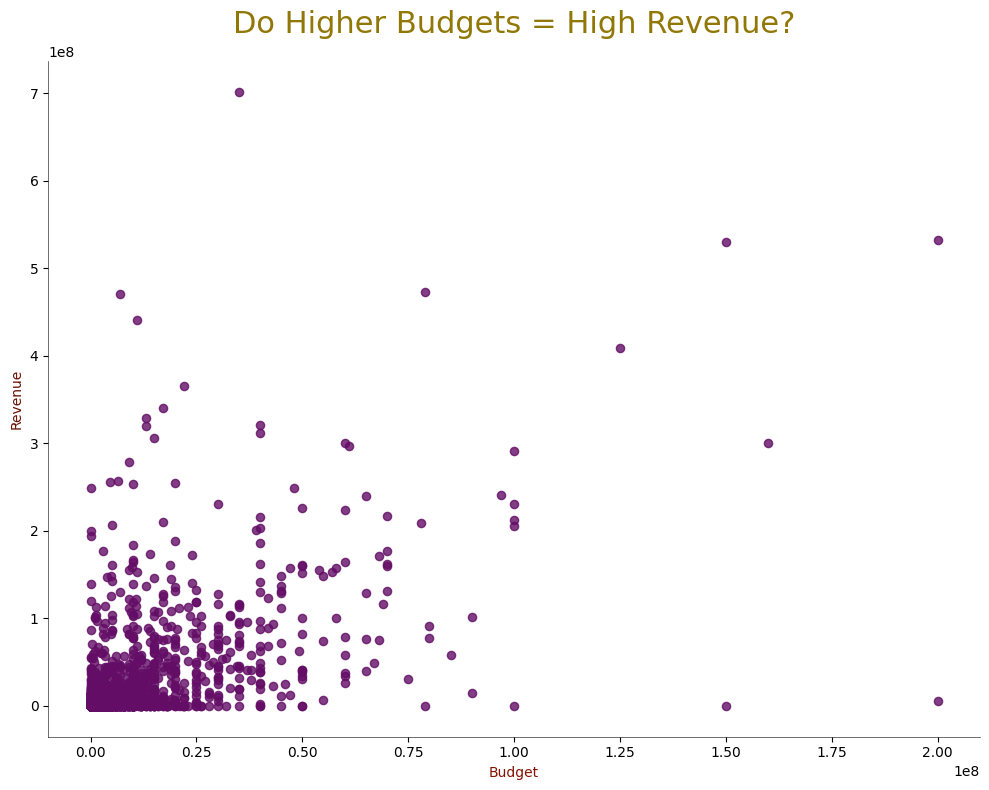

In [108]:
plt.figure(figsize=(10,8))
plt.scatter(movie_df['budget'], movie_df['revenue'], color = "#630d66", alpha= 0.8, s= 35)


plt.xlabel("Budget", color = "#851200" )
plt.ylabel("Revenue",  color = "#690f01")
plt.title("Do Higher Budgets = High Revenue?", fontsize=22, pad=20, color = "#917705")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(.50)
    spine.set_alpha(.8)

plt.tight_layout()
plt.savefig('../visuals/budget_revenue_corr.png')
plt.show()

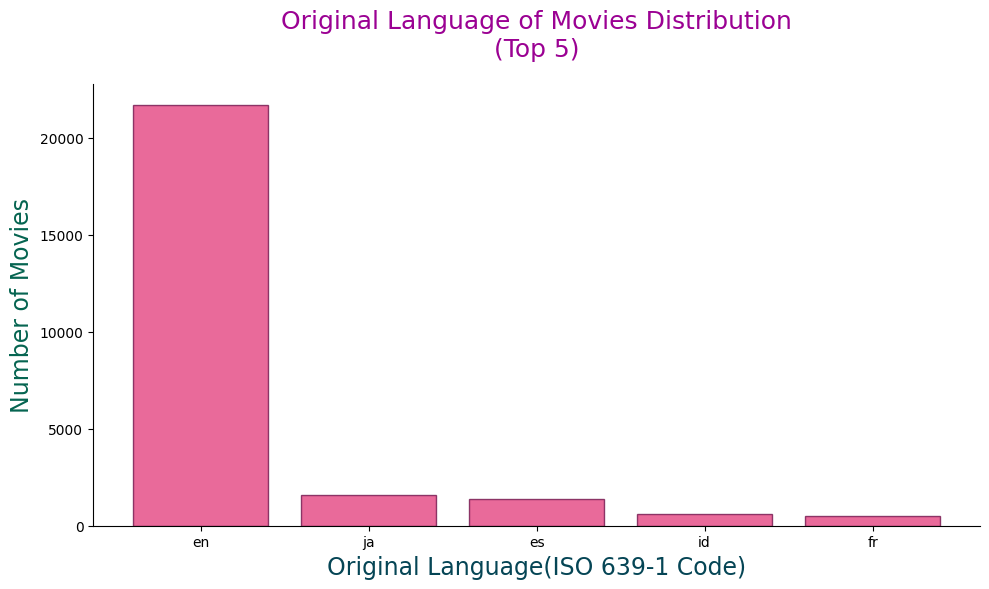

In [109]:
language_to_count = movie_df['original_language'].unique()
language_count = movie_df['original_language'].value_counts().get(language_to_count).sort_values(ascending=False)
#using ISO 639-1 Codes
# en = english
# ja = japanese
# es = spanish
# id = idonesian
# fr = french

plt.figure(figsize=(10,6))

plt.bar(
    language_count.head(5).index, 
    language_count.head(5).values, 
    color= "#e23879",
    alpha= 0.75,
    edgecolor= "#690944"
    )

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.xlabel("Original Language(ISO 639-1 Code)", color="#054555", fontsize=17)
plt.ylabel("Number of Movies", color= "#056450", fontsize=17)
plt.title("Original Language of Movies Distribution\n(Top 5)", fontsize=18, pad=20, color= "#9b0193")

plt.tight_layout()
plt.savefig('../visuals/originallanguage_distr.png')
plt.show()

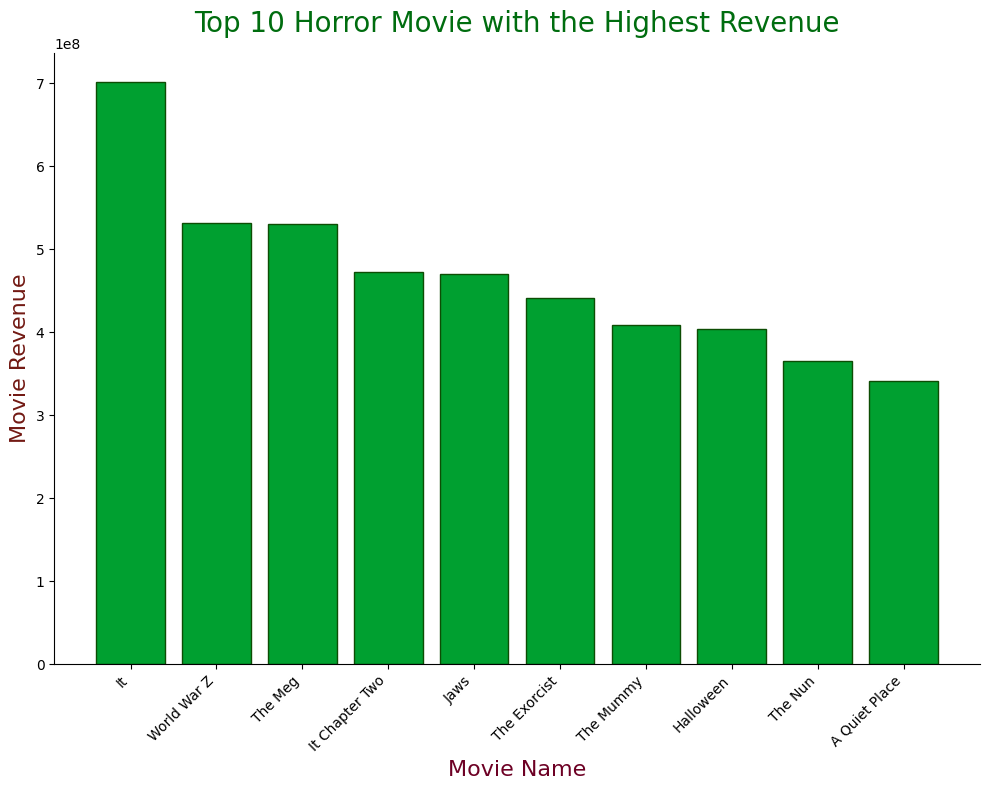

In [110]:
category = "title"
values = "revenue"
movie_rev = movie_df.groupby(category)[values].sum().sort_values(ascending=False)
movie_rev_10 = movie_rev.head(10)


plt.figure(figsize=(10,8))
plt.bar(movie_rev_10.index, movie_rev_10.values, color= "#00a030", edgecolor= "#0d4d04")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Top 10 Horror Movie with the Highest Revenue",
          fontsize= 20,
          color= "#006D0F",
          pad= 15,
          loc="center")
plt.xlabel("Movie Name", color="#6d0024", fontsize=16)
plt.ylabel("Movie Revenue", color= "#721913", fontsize=16)
plt.xticks(rotation=45, ha="right")


plt.tight_layout()
plt.savefig('../visuals/top10_movie_rev.png')
plt.show()



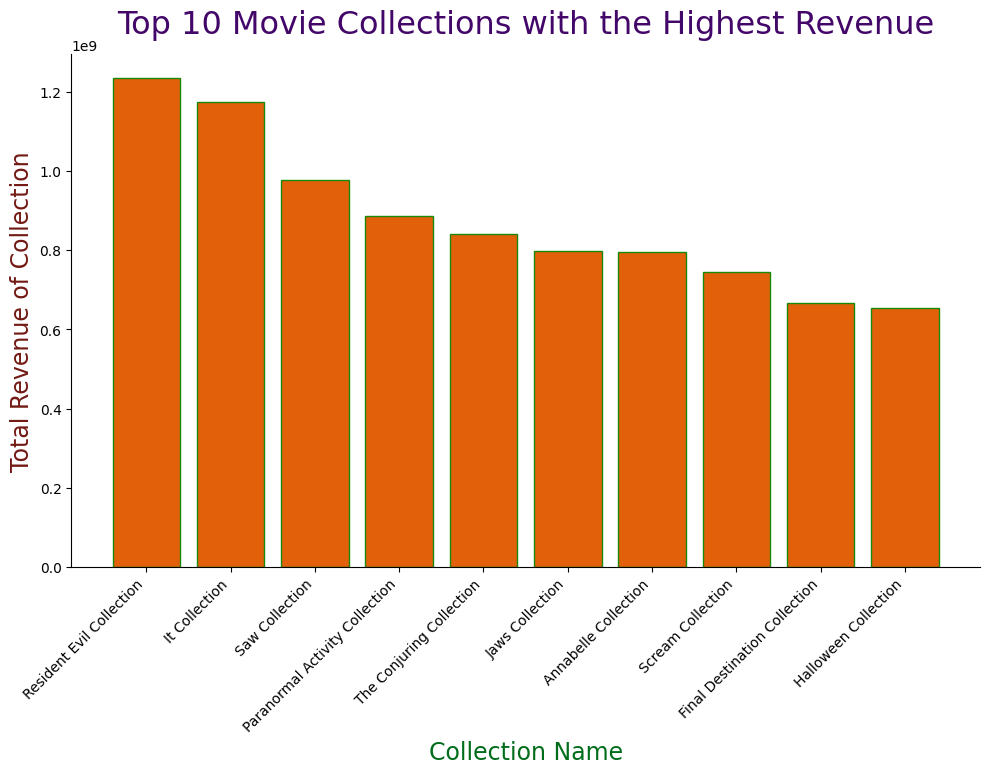

In [ ]:
category = "collection_name"
values = "revenue"
movie_collection_revenue = movie_df.groupby(category)[values].sum()
movie_coll_rev = movie_collection_revenue.sort_values(ascending=False) 

collection_rev_10 = movie_coll_rev.head(10)

plt.figure(figsize=(10,8))
plt.bar(collection_rev_10.index, collection_rev_10.values, color= "#e2600a", edgecolor= "#188a09")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Top 10 Movie Collections with the Highest Revenue",
          fontsize= 23,
          color= "#430669",
          pad= 15,
          loc="center")
plt.xlabel("Collection Name", color="#006d1b", fontsize=17)
plt.ylabel("Total Revenue of Collection", color= "#721913", fontsize=17)
plt.xticks(rotation=45, ha="right")


plt.tight_layout()
plt.savefig('../visuals/top_movie_collection_rev.png')
plt.show()



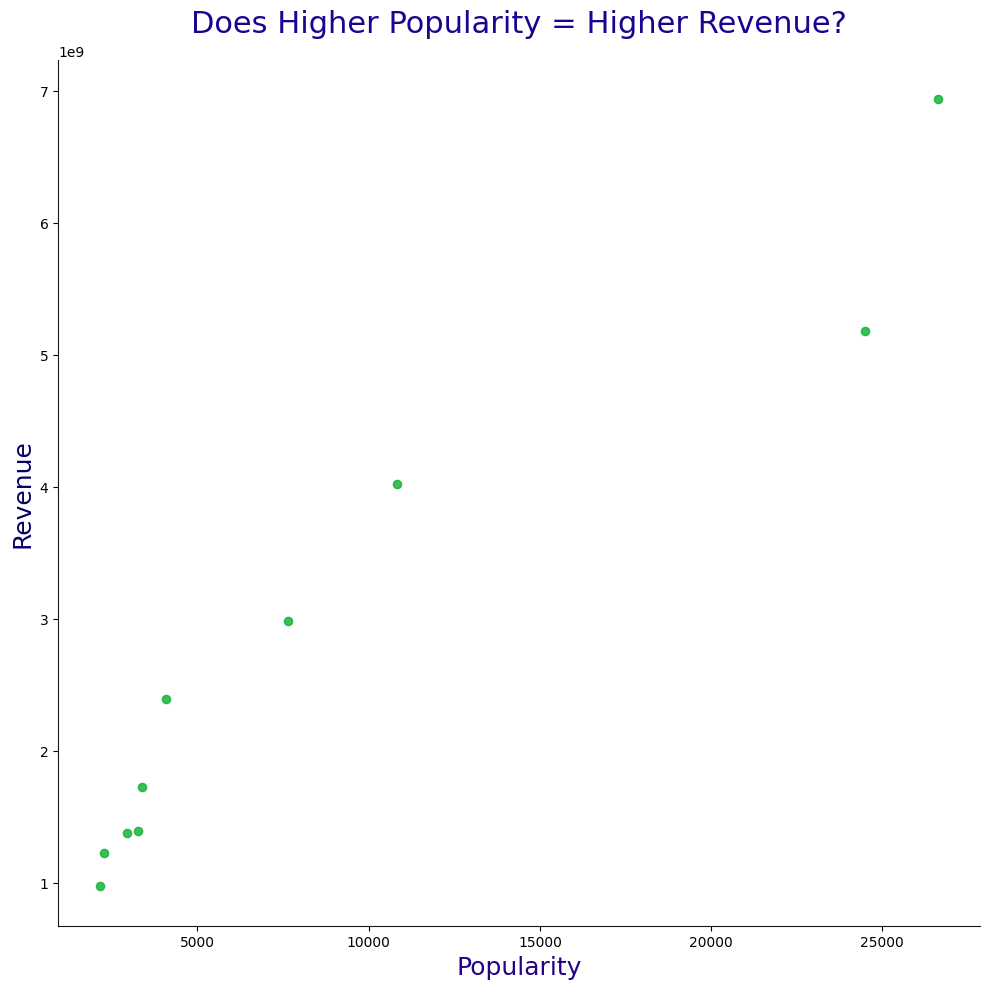

In [ ]:

top_pop_genre = movie_df.groupby("genre_names")["popularity"].sum().sort_values(ascending=False).head(10)
top_rev_genre = movie_df.groupby("genre_names")["revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,10))
plt.scatter(top_pop_genre, top_rev_genre, color = "#0baf2f", alpha= 0.8, s= 35)

plt.xlabel("Popularity", color = "#280085", fontsize=18 )
plt.ylabel("Revenue",  color = "#080169", fontsize=18)
plt.title("Does Higher Popularity = Higher Revenue?", fontsize=22, pad=20, color = "#1A0591")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(.80)
    spine.set_alpha(.9)

plt.tight_layout()
plt.savefig('../visuals/pop_vs_rev_top10.png')
plt.show()



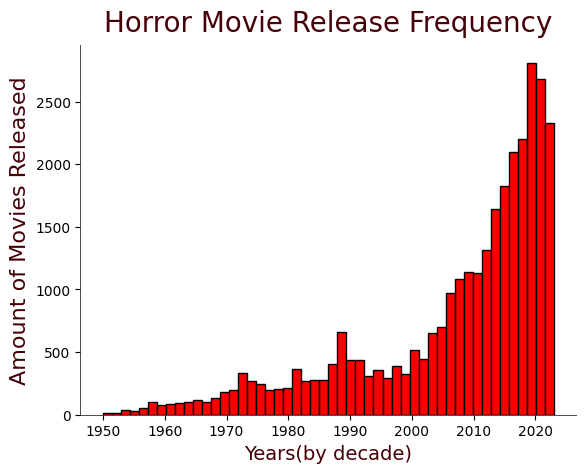

In [ ]:
release_data = movie_df['release_date']
plt.hist(release_data, bins=50, color="#fa0000", edgecolor="#000000")


plt.xlabel('Years(by decade)', fontsize=14, color= "#460007")
plt.ylabel('Amount of Movies Released',fontsize=16,  color= "#460007" )
plt.title('Horror Movie Release Frequency', fontsize=20, pad=10, color= "#460007")

ax= plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
    spine.set_alpha(0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig('../visuals/horror_movie_release_freq.png')
plt.show()

#spike in horror movies after trumps first term?? 

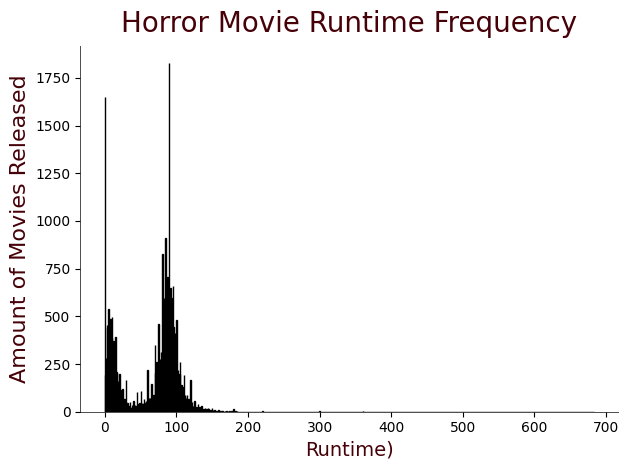

In [ ]:
runtime_data = movie_df['runtime']
plt.hist(runtime_data, bins=1000, color="#fa0000", edgecolor="#000000")


plt.xlabel('Runtime)', fontsize=14, color= "#460007")
plt.ylabel('Amount of Movies Released',fontsize=16,  color= "#460007" )
plt.title('Horror Movie Runtime Frequency', fontsize=20, pad=10, color= "#460007")

ax= plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
    spine.set_alpha(0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig('../visuals/horror_movie_runtime_freq.png')
plt.show()

#hmmmm 
#spike at zero... ? need to look into this 

#silent hill restless dreams = 33min(a short)
#infected: the darkest day = 121min 
#gomeda = 123min
# need to change 0s to NaN or something? 
# back to cleaning file..... 